# Phase 3.4 — Threshold simulation & the decoder benchmark

This is where Phase 3 becomes the capstone. We load the production sweeps written by
`scripts/run_threshold_sweep.py` (in `capstone/experiments/`), reproduce the
**threshold-crossing plot**, extract the threshold $p_\mathrm{th}$ and the
sub-threshold suppression factor $\Lambda = p_L(d)/p_L(d+2)$, and put **MWPM vs
BP+OSD** head to head on accuracy *and* latency.

Everything here uses the promoted analysis helpers in
:mod:`qec_project.analysis.threshold`; the numbers match `CHANGELOG.md`'s accuracy
table and `capstone/figures/summary.json` (same seed, same commit).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from qec_project.analysis.threshold import (
    estimate_threshold,
    filter_points,
    fit_critical,
    lambda_ratios,
    load_points,
)

repo = Path.cwd()
while not (repo / "capstone").exists() and repo.parent != repo:
    repo = repo.parent
exp = repo / "capstone" / "experiments"
# The committed sweeps behind the README numbers. A rerun writes new sweep-<date>-*
# directories next to them; point these two paths there to analyse it instead.
pm_csv = exp / "sweep-2026-06-19-pymatching-depolarizing" / "stats.csv"
bp_csv = exp / "sweep-2026-06-19-bp-osd-depolarizing" / "stats.csv"
points = load_points(pm_csv, bp_csv)
print(f"loaded {len(points)} points from\n  {pm_csv.parent.name}\n  {bp_csv.parent.name}")

loaded 45 points from
  sweep-2026-06-19-pymatching-depolarizing
  sweep-2026-06-19-bp-osd-depolarizing


## The threshold crossing (MWPM)

Below threshold, larger distance $\Rightarrow$ lower logical error; the curves
fan out. Above threshold the ordering inverts. They cross at $p_\mathrm{th}$.

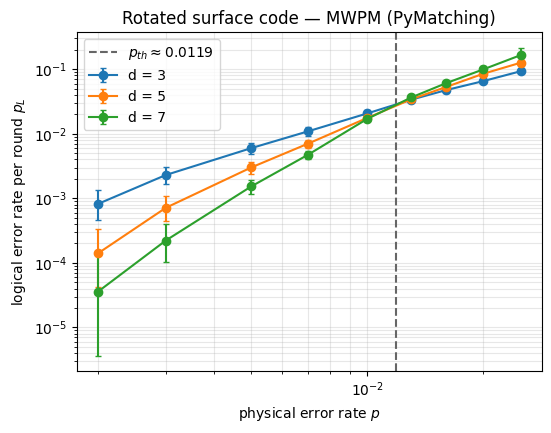

In [2]:
def plot_crossing(points, title):
    by_d = {}
    for p in points:
        by_d.setdefault(p.distance, []).append(p)
    plt.figure(figsize=(6, 4.4))
    for d in sorted(by_d):
        g = sorted(by_d[d], key=lambda q: q.p_phys)
        xs = [q.p_phys for q in g]
        ys = [q.p_log for q in g]
        yerr = [[max(q.p_log - q.p_log_low, 0) for q in g], [max(q.p_log_high - q.p_log, 0) for q in g]]
        plt.errorbar(xs, ys, yerr=yerr, marker="o", capsize=2, label=f"d = {d}")
    pth = estimate_threshold(points)
    plt.axvline(pth, ls="--", color="0.4", label=fr"$p_{{th}}\approx{pth:.4f}$")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("physical error rate $p$")
    plt.ylabel("logical error rate per round $p_L$")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

pm = filter_points(points, decoder="pymatching")
plot_crossing(pm, "Rotated surface code — MWPM (PyMatching)")

## Threshold & suppression for both decoders

`estimate_threshold` finds the curve crossing; `fit_critical` independently fits the
finite-size form $p_L = A\,(p/p_\mathrm{th})^{(d+1)/2}$. They agree to within the
fit error — a good consistency check. $\Lambda > 1$ confirms error suppression.

In [3]:
for dec in ("pymatching", "bp-osd"):
    pts = filter_points(points, decoder=dec)
    cross = estimate_threshold(pts)
    fit = fit_critical(pts)
    lam = {f"{a}->{b}": round(v, 2) for (a, b), v in lambda_ratios(pts).items()}
    print(f"{dec:>11}: crossing p_th = {cross:.4f} | fit p_th = {fit.p_th:.4f} "
          f"± {fit.p_th_stderr:.4f} | Λ = {lam}")

 pymatching: crossing p_th = 0.0119 | fit p_th = 0.0122 ± 0.0013 | Λ = {'3->5': 5.84, '5->7': 3.92}
     bp-osd: crossing p_th = 0.0132 | fit p_th = 0.0134 ± 0.0015 | Λ = {'3->5': 6.34}


## Head to head: accuracy vs time per shot

BP+OSD exploits the full hyperedge structure of the DEM, and on this data it has
**lower $p_L$ at $d=5$** than graph-based MWPM: significantly lower (two-proportion
$z > 2$) for $p = 0.005$ to $0.02$, on independently sampled (unpaired) shots. Its
fitted threshold overlaps MWPM's within fit error. But it is **far slower**, and the
cost gap grows steeply with distance. The timing below is wall time per shot for Stim
sampling plus decoding, batched, not a decoder-only latency. For the *Decoding
algorithm optimization* objective (real-time signal recovery), that scaling is the
crux.

In [4]:
import csv
from collections import defaultdict


def throughput(csv_path):
    agg = defaultdict(lambda: [0, 0.0])
    with open(csv_path) as f:
        for r in csv.DictReader(f):
            agg[int(r["distance"])][0] += int(r["shots"])
            agg[int(r["distance"])][1] += float(r["seconds"])
    return {d: (s / max(t, 1e-12)) for d, (s, t) in agg.items()}  # shots/sec

pm_tp, bp_tp = throughput(pm_csv), throughput(bp_csv)
print(f"{'d':>3} {'MWPM us/shot':>14} {'BP+OSD us/shot':>16} {'slowdown':>10}")
for d in sorted(set(pm_tp) & set(bp_tp)):
    pm_us, bp_us = 1e6 / pm_tp[d], 1e6 / bp_tp[d]
    print(f"{d:>3} {pm_us:>14.2f} {bp_us:>16.2f} {bp_us / pm_us:>9.0f}x")

# accuracy at a representative sub-threshold point
for dec, pts in (("MWPM", pm), ("BP+OSD", filter_points(points, decoder="bp-osd"))):
    q = next(x for x in pts if x.distance == 5 and abs(x.p_phys - 0.005) < 1e-9)
    print(f"{dec:>7} d=5 @ p=0.005: p_L = {q.p_log:.2e}")

  d   MWPM us/shot   BP+OSD us/shot   slowdown
  3           2.11           123.22        58x
  5           9.14          5368.93       587x
   MWPM d=5 @ p=0.005: p_L = 3.01e-03
 BP+OSD d=5 @ p=0.005: p_L = 1.93e-03


## Result

* **Threshold (uniform depolarizing).** The curves cross near
  $p_\mathrm{th}\approx 0.0119$ (MWPM) and $0.0132$ (BP+OSD); the fits give
  $0.0122\pm0.0013$ ($d=3,5,7$) and $0.0134\pm0.0015$ ($d=3,5$), which overlap
  within fit error. BP+OSD's measured edge is lower $p_L$ at $d=5$: 11 to 35% lower
  per shot for $p = 0.003$ to $0.01$ (35% at $p = 0.005$), significant only for
  $p=0.005$ to $0.02$. The $\Lambda$ printed above
  is taken at $p=0.002$, where the cells hold 5 to 49 logical errors, so it does not
  rank the decoders; `scripts/lambda_interval.py` gives $\Lambda$ at $p=0.005$ with an
  interval.
* **Time per shot (sampling + decoding).** BP+OSD takes ~58$\times$ as long as MWPM
  at $d=3$ and ~590$\times$ at $d=5$ on identical hardware; the gap widens with
  distance.
* **Takeaway for the capstone.** Accuracy and real-time feasibility pull in opposite
  directions. Quantifying that frontier under realistic noise is exactly the NRC
  *Decoding algorithm optimization* question — see `capstone/`.

> Noise model: `depolarizing` = all four Stim circuit-noise knobs set to $p$. The
> threshold is specific to this model and is **not** a published circuit-level
> (e.g. SI1000) number; it is an identical baseline for the decoder *comparison*.